In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Add the parent directory to the path so we can import from 'core'
sys.path.append(os.path.abspath('..'))

# Import your specific environment builder
# (Adjust this import if your make_env is located elsewhere)
from core.helpers import make_env
from core.configs import shared_config as config
# Create the Envpool environment wrapped with your JaxEnvPoolWrapper
config['ENV_NAME'] = 'MontezumaRevenge-v5'
config['NUM_ENVS'] = 1
env = make_env(config)

print(f"Environment initialized: {env.env_name}")
print(f"Number of parallel environments: {env.num_envs}")

/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/flax/linen/module.py:77: DeprecationWarning: jax.random.KeyArray is deprecated. Use jax.Array for annotations, and jax.dtypes.issubdtype(arr, jax.dtypes.prng_key) for runtime detection of typed prng keys.
  KeyArray = Union[jax.Array, jax.random.KeyArray]  # pylint: disable=invalid-name
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/flax/linen/recurrent.py:45: DeprecationWarning: jax.random.KeyArray is deprecated. Use jax.Array for annotations, and jax.dtypes.issubdtype(arr, jax.dtypes.prng_key) for runtime detection of typed prng keys.
  PRNGKey = jax.random.KeyArray
/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/flax/linen/stochastic.py:28: DeprecationWarning: jax.random.KeyArray is deprecated. Use jax.Array for annotations, and jax.dtypes.issubdtype(arr, jax.dtypes.prng_key) for runtime detection of typed prng keys.
  Key

Environment initialized: MontezumaRevenge-v5
Number of parallel environments: 1


/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/envpool/python/xla_template.py:94: DeprecationWarning: jax.interpreters.xla.backend_specific_translations is deprecated. Register custom primitives via jax.interpreters.mlir instead.
  xla.backend_specific_translations["cpu"][prim] = partial(


In [2]:
rng = jax.random.PRNGKey(42)

# Reset environment
obs, env_state = env.reset()

trajectory = []
done_seen = False
steps_after_done = 0
max_steps = 2000 # Safety limit

print("Collecting trajectory...")
for i in range(max_steps):
    rng, action_rng = jax.random.split(rng)
    
    # Breakout has 4 actions (0: NOOP, 1: FIRE, 2: RIGHT, 3: LEFT)
    # Using random actions to ensure we eventually miss the ball and lose a life/die
    actions = jax.random.randint(action_rng, (env.num_envs,), 0, 4)
    
    # Step your custom wrapper
    next_obs, next_env_state, raw_rewards, dones, infos = env.step(env_state, actions)
    
    # Store the transition for env_id = 0
    trajectory.append({
        'step_idx': i,
        'obs': np.array(obs[0]), 
        'next_obs': np.array(next_obs[0]),
        'action': int(actions[0]),
        'reward': float(raw_rewards[0]),
        'done': bool(dones[0]),
        'is_dummy': bool(infos['is_dummy'][0]),
        'is_goal': bool(infos['is_goal'][0]),
        'was_goal': bool(infos['was_goal'][0]),
        'lives': int(infos.get('lives', jnp.zeros_like(dones))[0])
    })
    
    obs = next_obs
    env_state = next_env_state
    
    if dones[0]:
        done_seen = True
        
    if done_seen:
        steps_after_done += 1
        
    # Stop collecting 2 steps after we see the done flag
    if steps_after_done >= 3:
        break

print(f"Done! Collected {len(trajectory)} transitions.")

# Find the exact index where the game ended
death_idx = next(i for i, step in enumerate(trajectory) if step['done'])
print(f"Death/Reset occurred at transition index: {death_idx}")

I0000 00:00:1777563678.727856 1180260 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Done! Collected 232 transitions.
Death/Reset occurred at transition index: 229


In [3]:
def visualize_transition(t, transition, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    obs = transition['obs']
    next_obs = transition['next_obs']
    
    # Handle Framestacking (Envpool returns [C, H, W] or [H, W, C])
    # We grab the last frame in the stack to see the most recent physical state
    if obs.shape[0] == 4 or obs.shape[-1] == 4:
        frame_idx = -1 if obs.shape[0] == 4 else 3 # channel first vs last
        o_plot = obs[frame_idx] if obs.shape[0] == 4 else obs[..., frame_idx]
        no_plot = next_obs[frame_idx] if next_obs.shape[0] == 4 else next_obs[..., frame_idx]
    else:
        o_plot, no_plot = obs, next_obs
        
    axes[0].imshow(o_plot, cmap='gray')
    axes[0].set_title(f"State (Obs)")
    axes[0].axis('off')
    
    axes[1].imshow(no_plot, cmap='gray')
    axes[1].set_title(f"Next State (Next Obs)")
    axes[1].axis('off')
    
    plt.suptitle(f"{title} (Buffer Index: {t})", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"--- Information Flags for Transition {t} ---")
    print(f"Action Taken: {transition['action']}")
    print(f"Reward:       {transition['reward']}")
    print(f"Done:         {transition['done']}")
    print(f"is_dummy:     {transition['is_dummy']}")
    print(f"is_goal:      {transition['is_goal']}")
    print(f"was_goal:     {transition['was_goal']}")
    print(f"Lives:        {transition['lives']}")
    print("-" * 45)

/home/users/ds541/.pyenv/versions/3.10.15/envs/atari-env/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


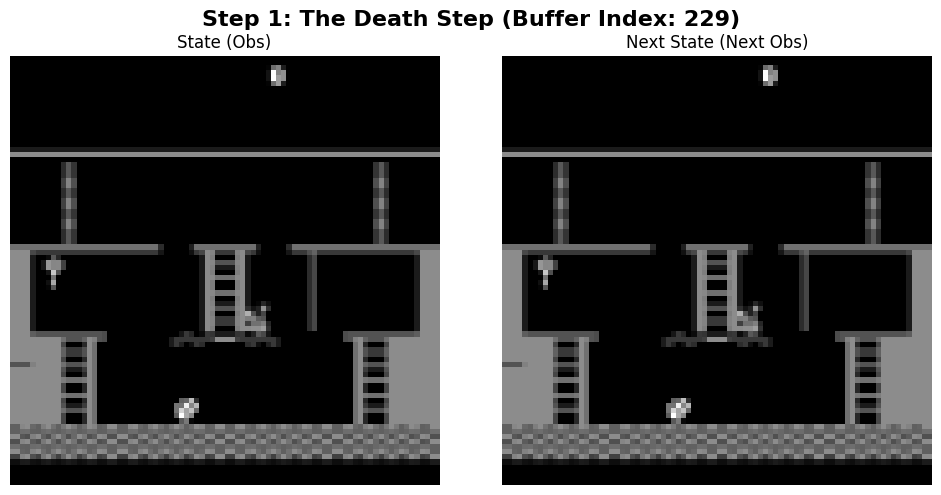

--- Information Flags for Transition 229 ---
Action Taken: 0
Reward:       0.0
Done:         True
is_dummy:     False
is_goal:      False
was_goal:     False
Lives:        0
---------------------------------------------


In [4]:
# The transition where done=True
visualize_transition(
    death_idx, 
    trajectory[death_idx], 
    "Step 1: The Death Step"
)

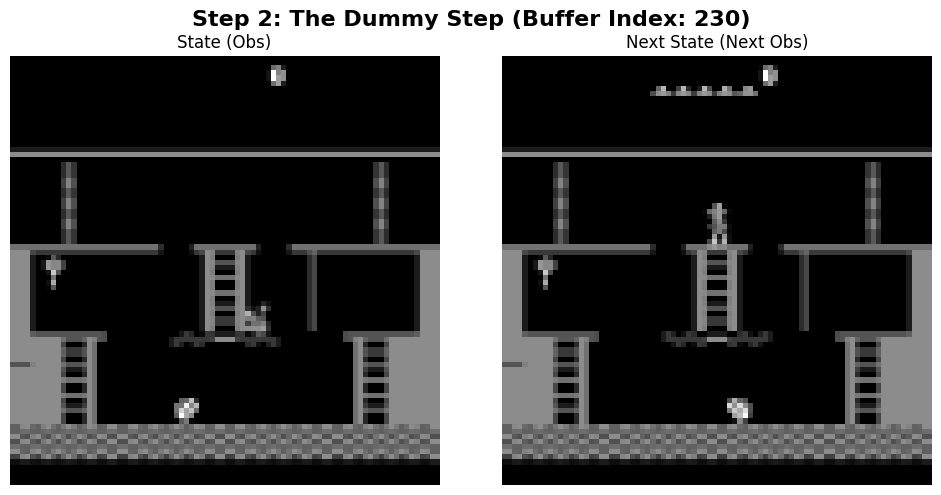

--- Information Flags for Transition 230 ---
Action Taken: 2
Reward:       0.0
Done:         False
is_dummy:     True
is_goal:      False
was_goal:     False
Lives:        0
---------------------------------------------


In [5]:
# The transition immediately following done=True
visualize_transition(
    death_idx + 1, 
    trajectory[death_idx + 1], 
    "Step 2: The Dummy Step"
)

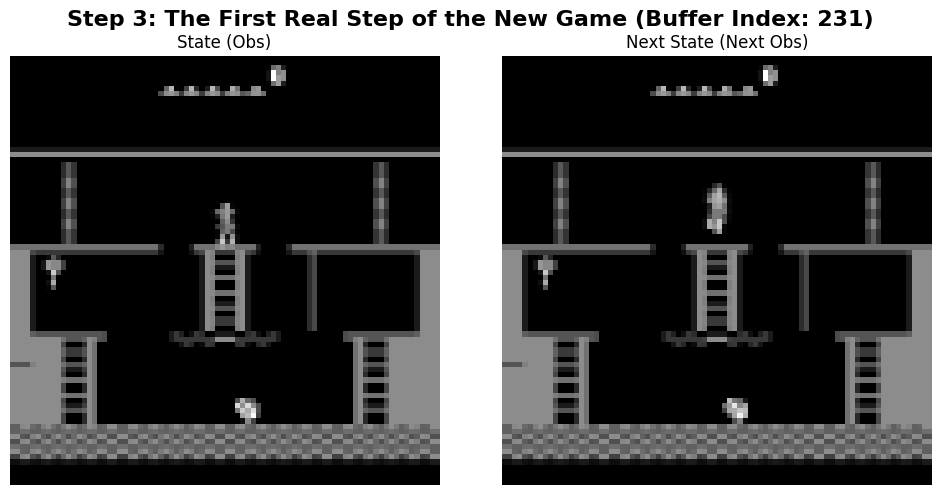

--- Information Flags for Transition 231 ---
Action Taken: 0
Reward:       0.0
Done:         False
is_dummy:     False
is_goal:      False
was_goal:     False
Lives:        0
---------------------------------------------


In [6]:
# Two transitions after done=True
visualize_transition(
    death_idx + 2, 
    trajectory[death_idx + 2], 
    "Step 3: The First Real Step of the New Game"
)

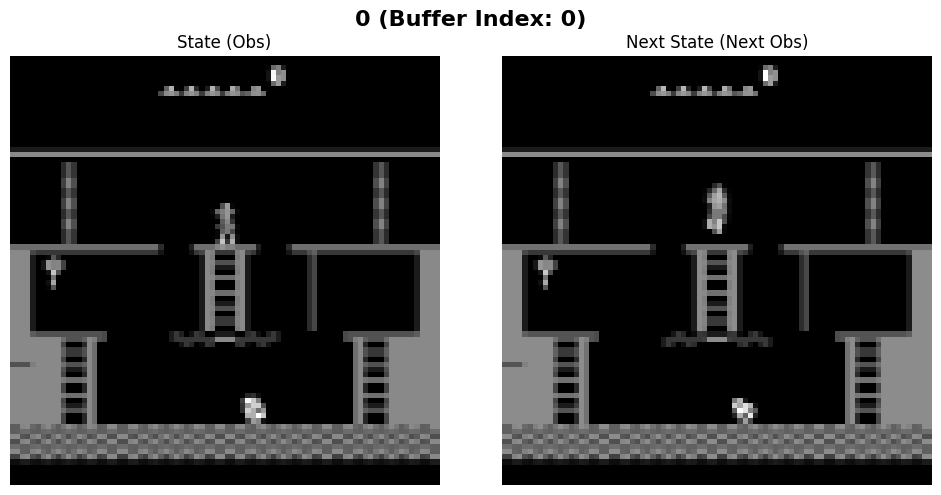

--- Information Flags for Transition 0 ---
Action Taken: 3
Reward:       0.0
Done:         False
is_dummy:     False
is_goal:      False
was_goal:     False
Lives:        0
---------------------------------------------


In [7]:
# The transition where done=True
visualize_transition(
    0, 
    trajectory[0], 
    "0"
)

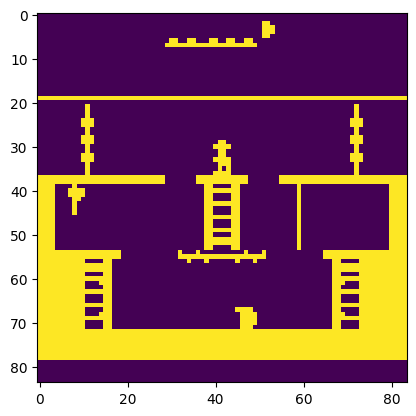

In [8]:
plt.imshow(trajectory[0]['obs'][0]>50)

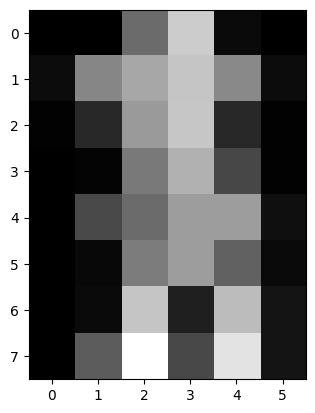

In [9]:
plt.imshow(trajectory[0]['obs'][0][29:37,39:45],cmap='grey')

In [10]:
joe_pixels = np.unique(trajectory[0]['obs'][0][29:37,39:45])
# joe_pixels = joe_pixels[1:]
joe_pixels=joe_pixels[5:]
joe_pixels

array([  9,  11,  14,  22,  28,  50,  51,  52,  65,  68,  75,  85,  87,
        94,  96, 108, 110, 117, 124, 132, 138, 139, 143, 160, 179],
      dtype=uint8)

In [11]:
# The specific pixels you identified

def filter_for_joe(obs, signature=joe_pixels):
    """
    Input: obs of shape (C, H, W) or (B, C, H, W)
    Output: Same shape, but with only Joe's pixels retained.
    """
    # Create a boolean mask: True where the pixel value is in Joe's signature
    mask = jnp.isin(obs, signature)
    
    # Use jnp.where to keep Joe's original pixels and zero out the rest
    # This preserves the 'internal' detail of the agent
    joe_only_obs = jnp.where(mask, obs, 0)
    
    return joe_only_obs

In [ ]:
def detect_joe_block(obs):
    joe_pixels = [  9,  11,  14,  22,  28,  50,  51,  52,  65,  68,  75,  85,  87,
        94,  96, 108, 110, 117, 124, 132, 138, 139, 143, 160, 179]
    joe_pixels = jnp.array(joe_pixels)
    # 1. Handle Input Shape
    # obs might be (H, W), (C, H, W), or (B, C, H, W)
    # We want it to be (Batch, Channel, Height, Width)
    if obs.ndim == 2:
        x = obs[None, None, :, :]
    elif obs.ndim == 3:
        x = obs[None, :, :, :]
    else:
        x = obs

    # 2. Get color mask: 1.0 where Joe's pixels are present
    color_mask = jnp.isin(x, joe_pixels).astype(jnp.float32)
    
    # 3. Create the Kernel: (8, 6)
    # Kernel must be 4D: (Output_Channels, Input_Channels, K_Height, K_Width)
    # Since we are just summing, O and I are both 1.
    kernel = jnp.ones((1, 1, 8, 6), dtype=jnp.float32)
    
    # 4. Perform Convolution
    # This sums up Joe-pixels in every 8x6 window
    pixel_counts = jax.lax.conv_general_dilated(
        color_mask,    # lhs
        kernel,        # rhs
        window_strides=(1, 1),
        padding='SAME',
        dimension_numbers=('NCHW', 'OIHW', 'NCHW')
    )
    
    # 5. Threshold: Does this 8x6 block contain enough Joe?
    # Joe is ~48 pixels total. 15-20 is a safe threshold for movement/climbing.
    joe_presence_mask = (pixel_counts > 15.0).astype(jnp.float32)
    
    # 6. Final Filter: Return original obs but zero out non-Joe areas
    # We squeeze back to match the input rank at the very end
    filtered = jnp.where(joe_presence_mask > 0, x, 0)
    
    return jnp.reshape(filtered, obs.shape)

def get_joe_int_coords(filtered_obs):
    # filtered_obs: (84, 84)
    yy, xx = jnp.indices(filtered_obs.shape)
    mask = (filtered_obs > 0).astype(jnp.float32)
    total = jnp.sum(mask) + 1e-8
    
    # Calculate floats
    avg_x = jnp.sum(mask * xx) / total
    avg_y = jnp.sum(mask * yy) / total
    
    # Round and cast to int for array indexing
    # We clip to ensure Joe doesn't "walk off" the array bounds
    return jnp.array([
        jnp.clip(jnp.round(avg_y), 0, 83).astype(jnp.int32), 
        jnp.clip(jnp.round(avg_x), 0, 83).astype(jnp.int32)
    ])

def create_batch_breadcrumb(centroids):
    # centroids: (Steps * Envs, 2) array of int coordinates
    canvas = jnp.zeros((84, 84), dtype=jnp.float32)
    
    # Use jnp.at[...].add() to "brighten" pixels Joe visits frequently
    # This creates a frequency heatmap rather than just a binary mask
    y_idx = centroids[:, 0]
    x_idx = centroids[:, 1]
    
    # This is a JAX-friendly way to update the canvas
    canvas = canvas.at[y_idx, x_idx].add(1.0)
    return canvas

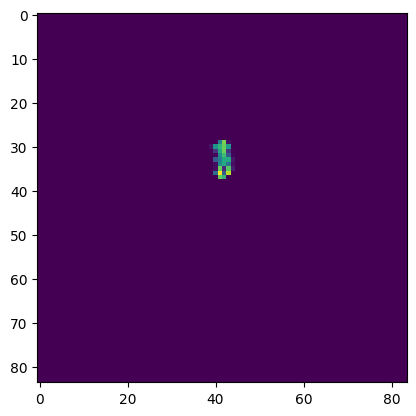

In [15]:
plt.imshow(detect_joe_block(trajectory[0]['obs'][0]))

In [30]:
jax.vmap(detect_joe_block)(trajectory[:]['obs'])

TypeError: list indices must be integers or slices, not str

In [25]:
trail_map = create_batch_breadcrumb(flat_coords)

NameError: name 'flat_coords' is not defined